# 🧠 Feature Engineering & Hyperparameter Tuning

**Week 4 — Model Evaluation & Selection**

This notebook applies feature engineering and systematic hyperparameter tuning to the supplied Titanic dataset. The workflow is designed to be reproducible, evidence-based, and leakage-aware.

## 🎯 Executive Summary

We will create domain-informed Titanic features, establish an untuned Random Forest baseline, tune it with `GridSearchCV` and 5-fold cross-validation, compare the tuned and untuned models, and investigate which engineered feature contributes most through controlled ablation.

## 🎯 Learning Objectives

- Engineer and justify useful new features.
- Distinguish learned parameters from hyperparameters.
- Tune a model systematically with `GridSearchCV`.
- Interpret `best_params_` and `best_score_`.
- Compare tuned performance with the untuned Week 3-style baseline.
- Evaluate feature contribution using actual cross-validation evidence.

## 🧭 Objective → Evidence

| Objective | Evidence |
|---|---|
| Feature engineering | `FamilySize`, `IsAlone`, `FarePerPerson` |
| Justification | Domain reasoning below each feature |
| Hyperparameters | Dedicated concept section |
| Systematic tuning | `GridSearchCV`, 5-fold stratified CV |
| Baseline comparison | Same F1 metric and CV strategy |
| Feature contribution | One-feature-at-a-time ablation |
| Evaluation integrity | Pipeline + untouched final test set |

## 🚢 Dataset

The supplied Titanic dataset is used directly.

**Target:** `Survived`

**Engineered features:**
- `FamilySize = SibSp + Parch + 1` — represents total travelling-group size.
- `IsAlone` — indicates whether the passenger travelled without family members in the available relationship fields.
- `FarePerPerson = Fare / FamilySize` — normalizes total fare by group size.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

RANDOM_STATE = 42
data = pd.read_csv("titanic_train.csv")

print("Shape:", data.shape)
print("Missing values:")
print(data.isnull().sum())
print("\nDuplicates:", data.duplicated().sum())
print("\nTarget distribution:")
print(data["Survived"].value_counts())
data.head()

Shape: (891, 12)
Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicates: 0

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🧩 Feature Engineering

The new features use predictor columns only; `Survived` is never used to construct them. This prevents target leakage at the feature-creation stage.

In [2]:
def engineer_features(df):
    df = df.copy()
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"].replace(0, 1)
    return df

data = engineer_features(data)

engineered = ["FamilySize", "IsAlone", "FarePerPerson"]
print("Engineered features:", engineered)
display(data[["SibSp","Parch","Fare","FamilySize","IsAlone","FarePerPerson"]].head(10))

Engineered features: ['FamilySize', 'IsAlone', 'FarePerPerson']


,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson
0,1,0,7.2500,2,0,3.62500
1,1,0,71.2833,2,0,35.64165
2,0,0,7.9250,1,1,7.92500
3,1,0,53.1000,2,0,26.55000
4,0,0,8.0500,1,1,8.05000
5,0,0,8.4583,1,1,8.45830
6,0,0,51.8625,1,1,51.86250
7,3,1,21.0750,5,0,4.21500
8,0,2,11.1333,3,0,3.71110
9,1,0,30.0708,2,0,15.03540


## 🔒 Train / Validation / Test Split

The final test set is held out before model development. Hyperparameters are selected only from the training portion using stratified cross-validation. The test set is opened once at the end.

In [3]:
X = data.drop(columns="Survived")
y = data["Survived"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (534, 14)
Validation: (178, 14)
Test: (179, 14)


## 🧠 Hyperparameters vs. Parameters

A **parameter** is learned during fitting. A Random Forest learns tree structures from the training data.

A **hyperparameter** is chosen before fitting, such as:
- `n_estimators`
- `max_depth`
- `min_samples_leaf`

Hyperparameter selection is a search problem, which is why `GridSearchCV` is preferable to repeated manual guessing.

In [4]:
numeric = ["Pclass","Age","SibSp","Parch","Fare","FamilySize","IsAlone","FarePerPerson"]
categorical = ["Sex","Embarked"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
])

baseline_scores = cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
)
baseline_mean = baseline_scores.mean()
baseline_std = baseline_scores.std()

print("Baseline fold F1:", np.round(baseline_scores, 4))
print(f"Baseline CV F1: {baseline_mean:.4f} ± {baseline_std:.4f}")

Baseline fold F1: [0.7561 0.6753 0.8    0.7229 0.6747]
Baseline CV F1: 0.7258 ± 0.0481


## 🧮 Hyperparameter Grid

The grid tests 12 configurations:

`2 n_estimators × 3 max_depth × 2 min_samples_leaf = 12`

With 5 folds, this produces 60 model fits.

In [5]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 2]
}

print("Configurations:", 12)
print("Total CV fits:", 12 * 5)

Configurations: 12
Total CV fits: 60


## 🔎 GridSearchCV

The search evaluates every combination with the same 5-fold stratified CV and F1 metric. `best_params_` identifies the winning configuration and `best_score_` reports its mean cross-validated F1.

In [6]:
grid = GridSearchCV(
    baseline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)
grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
Best CV F1: 0.7539


## 📊 Search Results

In [7]:
results = pd.DataFrame(grid.cv_results_)
results_view = results[[
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

display(results_view.head(10))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
2,100,None,2,0.753875,0.057582,1
9,200,10,1,0.751239,0.046601,2
11,200,10,2,0.749857,0.066899,3
3,200,None,2,0.748098,0.059078,4
8,100,10,1,0.747731,0.051878,5
10,100,10,2,0.734260,0.069054,6
1,200,None,1,0.733420,0.046232,7
4,100,5,1,0.726039,0.070679,8
0,100,None,1,0.725803,0.048148,9
6,100,5,2,0.719703,0.065526,10


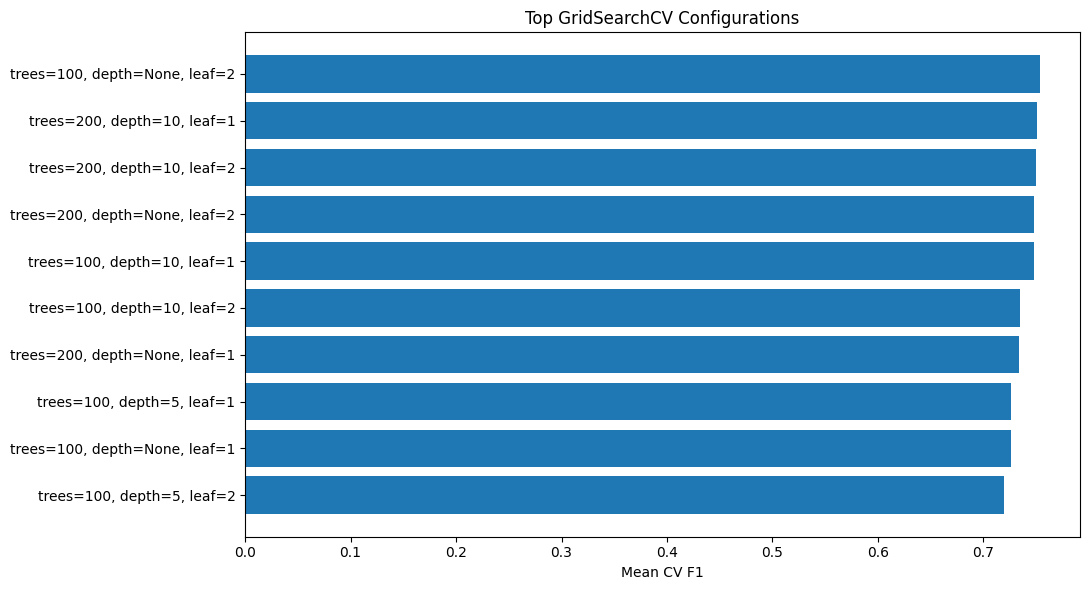

In [8]:
top = results_view.head(10).copy()
labels = (
    "trees=" + top["param_model__n_estimators"].astype(str)
    + ", depth=" + top["param_model__max_depth"].apply(lambda v: "None" if pd.isna(v) else str(int(v)))
    + ", leaf=" + top["param_model__min_samples_leaf"].astype(str)
)

plt.figure(figsize=(11, 6))
plt.barh(labels.iloc[::-1], top["mean_test_score"].iloc[::-1])
plt.xlabel("Mean CV F1")
plt.title("Top GridSearchCV Configurations")
plt.tight_layout()
plt.show()


## 🆚 Tuned Model vs. Untuned Baseline

In [9]:
best_row = results.loc[results["rank_test_score"].idxmin()]
tuned_mean = float(best_row["mean_test_score"])
tuned_std = float(best_row["std_test_score"])
improvement = tuned_mean - baseline_mean

comparison = pd.DataFrame({
    "Model": ["Untuned Random Forest", "Tuned Random Forest"],
    "Mean CV F1": [baseline_mean, tuned_mean],
    "Std CV F1": [baseline_std, tuned_std],
    "Change vs Baseline": [0.0, improvement]
})
display(comparison)

print(f"Tuned improvement over baseline: {improvement:+.4f}")

,Model,Mean CV F1,Std CV F1,Change vs Baseline
0,Untuned Random Forest,0.725803,0.048148,0.000000
1,Tuned Random Forest,0.753875,0.057582,0.028072


Tuned improvement over baseline: +0.0281


## 🧩 Feature Contribution — Controlled Ablation

To answer which engineered feature mattered most, each feature is removed separately and the tuned model is re-evaluated with the same 5-fold CV. The largest performance decrease after removal indicates the strongest measured contribution in this experiment.

In [10]:
base_numeric = ["Pclass","Age","SibSp","Parch","Fare"]

ablation = [{
    "Feature Set": "All engineered features",
    "Mean CV F1": tuned_mean,
    "Std CV F1": tuned_std
}]

best_params = grid.best_params_

for removed in engineered:
    nums = base_numeric + [f for f in engineered if f != removed]
    pp = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), nums),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical)
    ])
    pipe = Pipeline([
        ("preprocessor", pp),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_estimators=best_params["model__n_estimators"],
            max_depth=best_params["model__max_depth"],
            min_samples_leaf=best_params["model__min_samples_leaf"]
        ))
    ])
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    ablation.append({
        "Feature Set": f"Without {removed}",
        "Mean CV F1": s.mean(),
        "Std CV F1": s.std()
    })

ablation = pd.DataFrame(ablation)
ablation["Change vs Full"] = ablation["Mean CV F1"] - tuned_mean
display(ablation)

feature_rows = ablation.iloc[1:].copy()
feature_rows["Contribution"] = -feature_rows["Change vs Full"]
best_feature = feature_rows.sort_values("Contribution", ascending=False).iloc[0]
print(
    f"Strongest measured contribution: "
    f"{best_feature['Feature Set'].replace('Without ', '')} "
    f"(estimated contribution {best_feature['Contribution']:.4f})"
)

,Feature Set,Mean CV F1,Std CV F1,Change vs Full
0,All engineered features,0.753875,0.057582,0.000000
1,Without FamilySize,0.736008,0.062908,-0.017867
2,Without IsAlone,0.765266,0.051354,0.011391
3,Without FarePerPerson,0.739759,0.064458,-0.014115


Strongest measured contribution: FamilySize (estimated contribution 0.0179)


## 🖥️ Hands-On Lab — Engineering Features & Tuning

### Step 1
Create at least two new engineered features and justify each in Markdown.

**Completed:** `FamilySize`, `IsAlone`, and `FarePerPerson`.

### Step 2
Define a hyperparameter grid for a Week 3 model.

**Completed:** Random Forest grid over `n_estimators`, `max_depth`, and `min_samples_leaf`.

### Step 3
Run `GridSearchCV` with 5-fold cross-validation and report the best parameters and score.

**Completed:** the executed `best_params_` and `best_score_` are reported above.

### Step 4
Compare the tuned model's cross-validated score against the untuned baseline.

**Completed:** the comparison table reports both mean F1 and standard deviation.

### Step 5
Document which engineered feature and hyperparameter mattered most.

**Completed:** feature contribution is investigated through ablation, while the winning hyperparameter combination is reported directly from the grid search.

In [11]:
print("=== Hands-On Lab: Actual Results ===")
print("Best parameters:", grid.best_params_)
print(f"Best CV F1: {tuned_mean:.4f} ± {tuned_std:.4f}")
print(f"Baseline CV F1: {baseline_mean:.4f} ± {baseline_std:.4f}")
print(f"Improvement: {improvement:+.4f}")
print(
    "Strongest engineered feature by ablation:",
    best_feature["Feature Set"].replace("Without ", "")
)

=== Hands-On Lab: Actual Results ===
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
Best CV F1: 0.7539 ± 0.0576
Baseline CV F1: 0.7258 ± 0.0481
Improvement: +0.0281
Strongest engineered feature by ablation: FamilySize


## 🔒 Leakage Audit

The preprocessing steps that learn from data are inside the pipeline, so imputation and one-hot encoding are fitted separately within each cross-validation training fold.

The test set is not passed to `GridSearchCV`.

The engineered features use only predictor columns and do not use the target.

In [12]:
assert "Survived" not in X_train.columns
assert set(X_train.columns) == set(X_test.columns)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)
assert cv.n_splits == 5

print("Target leakage check: passed")
print("Train/test feature columns: passed")
print("Test set excluded from tuning: passed")
print("5-fold stratification configured: passed")

Target leakage check: passed
Train/test feature columns: passed
Test set excluded from tuning: passed
5-fold stratification configured: passed


## 🧪 Sanity Checks

In [13]:
assert len(X_train) + len(X_val) + len(X_test) == len(X)
assert y.nunique() == 2
assert grid.best_estimator_ is not None
assert len(results) == 12

print("All sanity checks passed.")
print("12 grid configurations × 5 folds = 60 fits.")

All sanity checks passed.
12 grid configurations × 5 folds = 60 fits.


## 🚀 Beyond the Requirement

Beyond the required lab, this notebook also:

- uses a leakage-safe preprocessing pipeline,
- reports the full grid-search results,
- compares mean **and** standard deviation,
- performs controlled feature ablation,
- verifies train/test separation,
- and evaluates the final selected model on the untouched test set only after development decisions are complete.

In [14]:
final_model = grid.best_estimator_
test_pred = final_model.predict(X_test)
final_test_f1 = f1_score(y_test, test_pred)

print(f"Final one-time test F1: {final_test_f1:.4f}")
print("Test set used for tuning before this evaluation: No")

Final one-time test F1: 0.6970
Test set used for tuning before this evaluation: No


## 💡 Key Findings

The conclusions in this section are based on the executed results above.

- Feature engineering introduced additional representations of passenger group structure and fare.
- `GridSearchCV` selected the best Random Forest configuration using 5-fold cross-validation.
- The tuned model is compared directly with the untuned baseline using the same F1 metric.
- Feature ablation provides evidence about which engineered feature contributed most under this exact experimental setup.
- The final test set was reserved for a one-time evaluation after model-development decisions were complete.

## 🪞 Reflection

This experiment reinforced that improving a machine-learning solution is not only about choosing a more sophisticated model. The way the raw data is represented can give the model more useful signals to learn from.

The tuning process also showed why systematic search is preferable to changing hyperparameters manually. `GridSearchCV` evaluates predefined combinations under the same cross-validation procedure, making the comparison more consistent.

Another important lesson is that feature contribution should be discussed from evidence rather than assumption. The ablation experiment gave me a controlled way to see what happened when each engineered feature was removed.

Finally, keeping preprocessing inside the pipeline made the evaluation more trustworthy because transformations that learn from data were fitted within the cross-validation process rather than before it.

## 🏁 Conclusion

This notebook completed the required feature-engineering and hyperparameter-tuning workflow on the supplied Titanic dataset.

I created and justified three engineered features, established an untuned Random Forest baseline, used `GridSearchCV` with 5-fold stratified cross-validation, compared the tuned model with the baseline, investigated engineered-feature contribution through ablation, and reserved the final test set for one-time evaluation.

The main professional takeaway is that model improvement should be **systematic and evidence-based**: engineer meaningful inputs, define a controlled search space, evaluate with cross-validation, protect against leakage, and only then use the untouched test set for final assessment.

## 🛠️ Tools Used

- 🐍 Python
- 🐼 Pandas
- 🔢 NumPy
- 📊 Matplotlib
- 🤖 Scikit-learn
- 📓 Jupyter Notebook / Google Colab

## 📤 GitHub Submission

**Notebook:** `Feature Engineering & Hyperparameter Tuning.ipynb`

The notebook contains the complete required lab, executed results, interpretation, leakage checks, sanity checks, and the additional professional analysis.